<a href="https://colab.research.google.com/github/BMateusSs/Projeto-PISI3/blob/main/mlp_analysis_wine_quality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Célula 1: Instalação das dependências (se ainda não tiver instalado)
%pip install --user scikit-learn imbalanced-learn pandas seaborn matplotlib pyarrow shap

In [ ]:
# Célula 2: Importação das bibliotecas
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier # Algoritmo principal desta análise
from sklearn.metrics import (
    accuracy_score, precision_score, precision_recall_curve, recall_score, f1_score, roc_curve, auc, classification_report, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')


In [ ]:
df = pd.read_parquet('wine-quality.parquet')
print("Colunas do dataset carregado:", df.columns.tolist())

Colunas do dataset carregado: ['type', 'fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


In [ ]:
# Target binária (quality > 5 = bom (1), <=5 ruim (0))
df['good_quality'] = (df['quality'] > 5).astype(int)
df.drop('quality', axis=1, inplace=True)

In [ ]:
# Encoding da variável 'type'
if df['type'].dtype == 'object':
    le = LabelEncoder()
    df['type'] = le.fit_transform(df['type'])
    print("Coluna 'type' codificada.")
else:
    print("Coluna 'type' já está numérica.")

Coluna 'type' codificada.



Distribuição das classes (good_quality):
good_quality
1    4113
0    2384
Name: count, dtype: int64


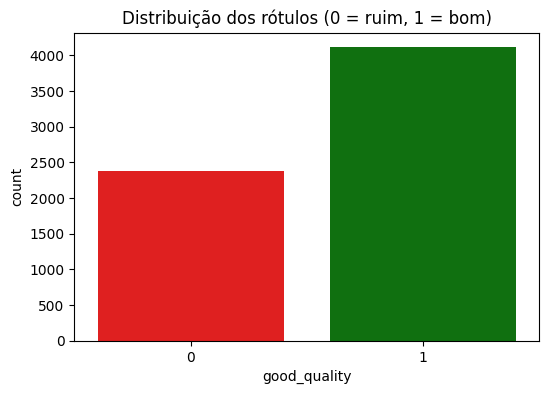

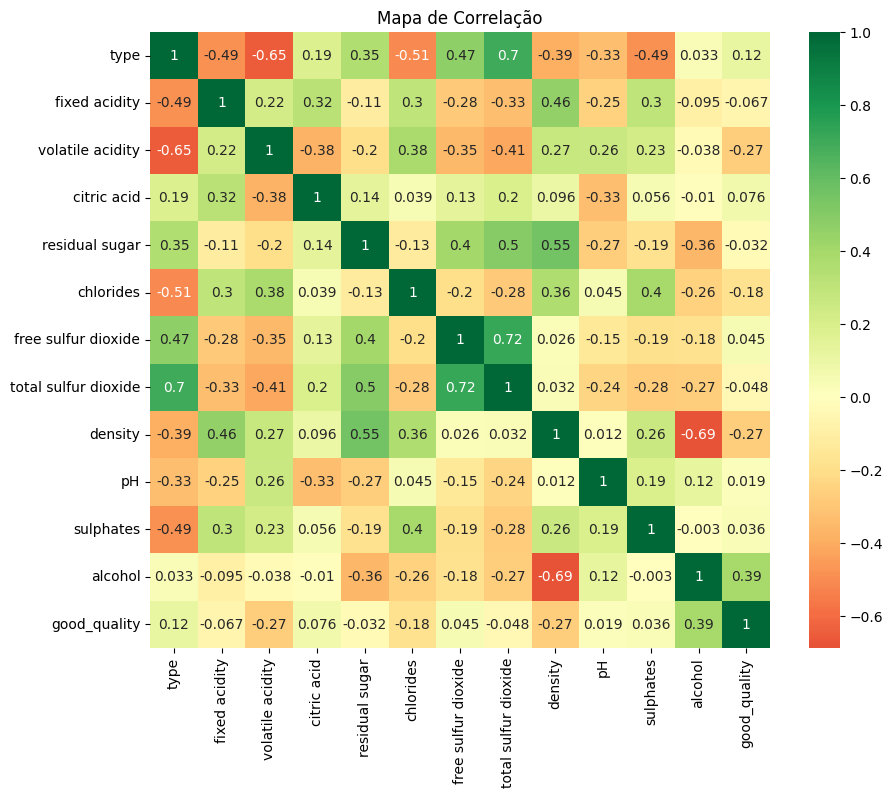

In [ ]:
# Análise das classes
print("\nDistribuição das classes (good_quality):")
print(df['good_quality'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x='good_quality', hue='good_quality', data=df, palette={0: 'red', 1: 'green'}, legend=False)
plt.title("Distribuição dos rótulos (0 = ruim, 1 = bom)")
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='RdYlGn', center=0)
plt.title("Mapa de Correlação")
plt.show()

In [ ]:
# X = variáveis independentes (características físico-químicas)
# y = variável dependente (qualidade do vinho)
X = df.drop('good_quality', axis=1)
y = df['good_quality']

In [ ]:
# Célula 7: Divisão em Conjuntos de Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# --- Seção Principal: MLP com Balanceamento SMOTE ---
# A normalização dos dados é CRUCIAL para o bom funcionamento de redes neurais.

print("\n--- INICIANDO TREINAMENTO: MLP (REDE NEURAL) + SMOTE ---")

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Aplicando a normalização (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

print(f"Distribuição de classes no treino original: {np.bincount(y_train)}")
print(f"Distribuição de classes após SMOTE: {np.bincount(y_train_smote)}")


--- INICIANDO TREINAMENTO: MLP (REDE NEURAL) + SMOTE ---
Distribuição de classes no treino original: [1907 3290]
Distribuição de classes após SMOTE: [3290 3290]


In [ ]:
# Célula 9: Treinamento do Modelo com GridSearchCV
def treinar_mlp_com_grid(X_train, y_train):
    """
    Treina um modelo MLP com busca de hiperparâmetros.
    """
    # Grade de parâmetros para a rede neural
    param_grid = {
        'hidden_layer_sizes': [(50, 50), (100,)], # Testar com 2 camadas de 50 neurônios ou 1 de 100
        'activation': ['relu', 'tanh'], # Funções de ativação a testar
        'solver': ['adam'],
        'alpha': [0.0001, 0.001], # Parâmetro de regularização L2
        'learning_rate': ['constant', 'adaptive'],
    }

    mlp = MLPClassifier(random_state=42, max_iter=300) # Aumentar max_iter para garantir convergência

    grid = GridSearchCV(
        estimator=mlp,
        param_grid=param_grid,
        cv=StratifiedKFold(n_splits=3),
        scoring='accuracy',
        verbose=1,
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    return grid.best_estimator_, grid.best_params_

best_mlp, best_params = treinar_mlp_com_grid(X_train_scaled, y_train_smote)
print("\nMelhores parâmetros encontrados (MLP + SMOTE):", best_params)


Fitting 3 folds for each of 16 candidates, totalling 48 fits

Melhores parâmetros encontrados (MLP + SMOTE): {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (50, 50), 'learning_rate': 'constant', 'solver': 'adam'}


In [ ]:
# Célula 10: Avaliação de Performance
y_pred = best_mlp.predict(X_test_scaled)
acc_test = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("\n===== Relatório de Classificação (MLP + SMOTE) =====")
print(report)
print(f"Acurácia final no Conjunto de Teste: {acc_test:.4f}")



===== Relatório de Classificação (MLP + SMOTE) =====
              precision    recall  f1-score   support

           0       0.66      0.74      0.70       477
           1       0.84      0.78      0.81       823

    accuracy                           0.76      1300
   macro avg       0.75      0.76      0.75      1300
weighted avg       0.77      0.76      0.77      1300

Acurácia final no Conjunto de Teste: 0.7646



--- Gerando Matriz de Confusão ---


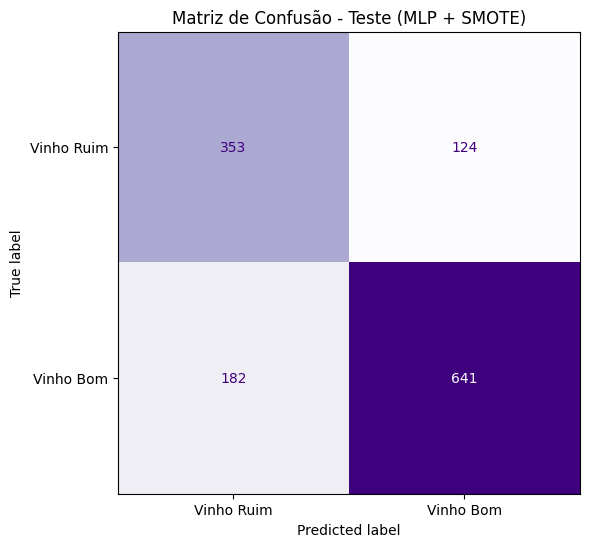

In [ ]:
# Célula 11: Matriz de Confusão (com nomes das classes)
print("\n--- Gerando Matriz de Confusão ---")

# Define os nomes das classes que queremos exibir
display_labels = ['Vinho Ruim', 'Vinho Bom']

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(
    best_mlp,
    X_test_scaled,
    y_test,
    ax=ax,
    cmap='Purples', # Paleta de cores roxas
    colorbar=False,
    display_labels=display_labels # Adicionado para mostrar os nomes
)
ax.set_title("Matriz de Confusão - Teste (MLP + SMOTE)")
plt.savefig("confusion_matrix_mlp_named.png")
plt.show()


--- Analisando importância das features com SHAP (pode levar alguns minutos) ---


  0%|          | 0/50 [00:00<?, ?it/s]

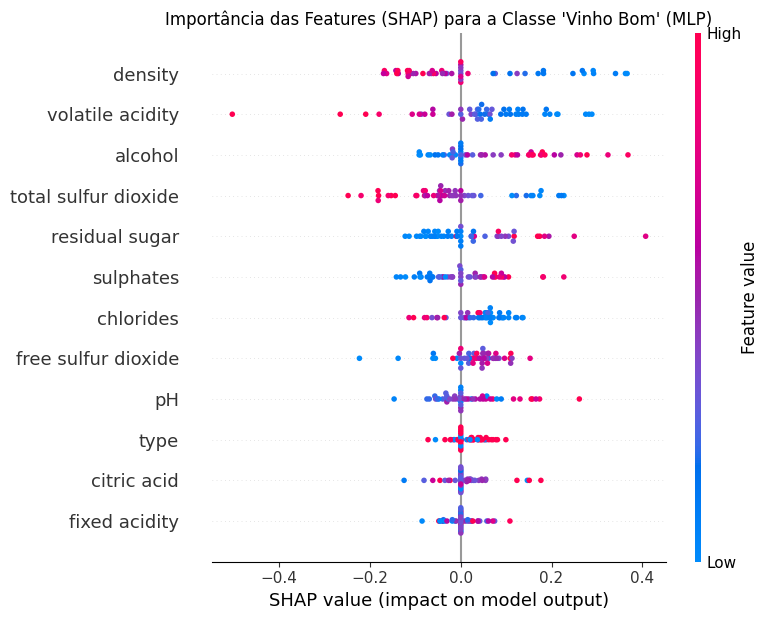

In [ ]:
# Célula 12: Análise de Features com SHAP
# Para MLP (modelo de caixa-preta), usamos o KernelExplainer.
# AVISO: Este processo pode ser LENTO, pois precisa de muitas predições para estimar os valores SHAP.
print("\n--- Analisando importância das features com SHAP (pode levar alguns minutos) ---")

# Para acelerar, usamos um subconjunto dos dados para criar o explainer
# Usando 100 amostras do treino para o fundo e 50 do teste para explicar
X_train_shap_sample = shap.sample(X_train_scaled, 100)
X_test_shap_sample = shap.sample(X_test_scaled, 50)

# Criamos o explainer com a função de predição de probabilidade do modelo
explainer = shap.KernelExplainer(best_mlp.predict_proba, X_train_shap_sample)
shap_values = explainer.shap_values(X_test_shap_sample)

# Plotar o resumo para a classe "Vinho Bom" (classe 1)
# Ajuste para multiclass: shap_values tem shape (samples, features, classes)
shap_values_class1 = shap_values[:, :, 1]
assert shap_values_class1.shape == X_test_shap_sample.shape, (
	f"Shape mismatch: shap_values_class1 {shap_values_class1.shape} vs X_test_shap_sample {X_test_shap_sample.shape}"
)
shap.summary_plot(shap_values_class1, X_test_shap_sample, feature_names=X.columns, show=False)
plt.title("Importância das Features (SHAP) para a Classe 'Vinho Bom' (MLP)")
plt.tight_layout()
plt.savefig("shap_summary_mlp.png")
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score

# --- ETAPA 5: Relatório de Classificação ---
target_names = ['Vinhos Ruins', 'Vinhos Bons']
report = classification_report(y_test, y_pred, target_names=target_names)

print("\n-----------------------------------------------------")
print("           Relatório de Classificação")
print("-----------------------------------------------------")
print(report)

# Calcular e mostrar as médias separadamente
precision_macro = precision_score(y_test, y_pred, average='macro')
recall_macro = recall_score(y_test, y_pred, average='macro')
f1_macro = f1_score(y_test, y_pred, average='macro')
precision_weighted = precision_score(y_test, y_pred, average='weighted')
recall_weighted = recall_score(y_test, y_pred, average='weighted')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

print(f"Média Simples (Macro): Precision={precision_macro:.2f}, Recall={recall_macro:.2f}, F1-Score={f1_macro:.2f}")
print(f"Média Ponderada:      Precision={precision_weighted:.2f}, Recall={recall_weighted:.2f}, F1-Score={f1_weighted:.2f}")
print("-----------------------------------------------------")


-----------------------------------------------------
           Relatório de Classificação
-----------------------------------------------------
              precision    recall  f1-score   support

Vinhos Ruins       0.66      0.74      0.70       477
 Vinhos Bons       0.84      0.78      0.81       823

    accuracy                           0.76      1300
   macro avg       0.75      0.76      0.75      1300
weighted avg       0.77      0.76      0.77      1300

Média Simples (Macro): Precision=0.75, Recall=0.76, F1-Score=0.75
Média Ponderada:      Precision=0.77, Recall=0.76, F1-Score=0.77
-----------------------------------------------------


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score

# --- ETAPA 1: Carregar os dados ---
df = pd.read_parquet('wine-quality.parquet')

# --- ETAPA 2: Criar variável alvo binária (0 = Ruim, 1 = Bom) ---
df['quality_label'] = df['quality'].apply(lambda x: 1 if x >= 7 else 0)

# --- ETAPA 3: Converter colunas categóricas em numéricas ---
df = pd.get_dummies(df, drop_first=True)

# Separar features (X) e target (y)
X = df.drop(['quality', 'quality_label'], axis=1)
y = df['quality_label']

# --- ETAPA 4: Dividir dados treino/teste ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# --- ETAPA 5: Normalizar dados ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- ETAPA 6: Treinar MLP ---
mlp = MLPClassifier(
    hidden_layer_sizes=(100,),  # 1 camada oculta com 100 neurônios
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)
mlp.fit(X_train_scaled, y_train)

# Prever resultados
y_pred = mlp.predict(X_test_scaled)

# --- ETAPA 7: Relatório de Classificação ---
target_names = ['Vinhos Ruins', 'Vinhos Bons']
report = classification_report(y_test, y_pred, target_names=target_names)

print("\n-----------------------------------------------------")
print("           Relatório de Classificação")
print("-----------------------------------------------------")
print(report)

# Calcular e mostrar as médias separadamente
precision_macro = precision_score(y_test, y_pred, average='macro')
recall_macro = recall_score(y_test, y_pred, average='macro')
f1_macro = f1_score(y_test, y_pred, average='macro')
precision_weighted = precision_score(y_test, y_pred, average='weighted')
recall_weighted = recall_score(y_test, y_pred, average='weighted')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

print(f"Média Simples (Macro): Precision={precision_macro:.2f}, Recall={recall_macro:.2f}, F1-Score={f1_macro:.2f}")
print(f"Média Ponderada:      Precision={precision_weighted:.2f}, Recall={recall_weighted:.2f}, F1-Score={f1_weighted:.2f}")
print("-----------------------------------------------------")



-----------------------------------------------------
           Relatório de Classificação
-----------------------------------------------------
              precision    recall  f1-score   support

Vinhos Ruins       0.89      0.92      0.90      1567
 Vinhos Bons       0.61      0.52      0.56       383

    accuracy                           0.84      1950
   macro avg       0.75      0.72      0.73      1950
weighted avg       0.83      0.84      0.84      1950

Média Simples (Macro): Precision=0.75, Recall=0.72, F1-Score=0.73
Média Ponderada:      Precision=0.83, Recall=0.84, F1-Score=0.84
-----------------------------------------------------
